# Stock Line Pixel Grid Clustering with J, F, H and Phi-space

This notebook runs the project step by step.

The goal is to start from a 2D stock-like line chart, treat the plotted objects as pixel-grid coordinates, calculate a third dimension `J(x,y)`, add higher-dimensional lifts `F` and `H`, cluster in the practical line-chart feature space

```text
Phi(x,y) = [x, y, slope, curvature, J, F, H]
```

and then plot the cluster results back on the original 2D chart.

## 1. Pixel grid and axes

The generated chart has a plot-grid origin at the axes intersection.

```text
x_grid = 0 on the y-axis
y_grid = 0 on the x-axis
```

Therefore the axes are easy to identify:

```text
x-axis points have the form J(x, 0)
y-axis points have the form J(0, y)
```

This notebook includes both axes as clusterable objects.

## 2. J, F, H and Phi

For line charts, the default project defines:

```text
J(x, y) = y
```

This makes `J` the chart height/value at that pixel.

Intersections are detected by comparing the two line J-sequences at the same x:

```text
intersection if J_line_1(x) = J_line_2(x)
```

The practical feature map is:

```text
Phi(x,y) = [x, y, slope, curvature, J, F, H]
```

with:

```text
slope      = local dy/dx
curvature  = local second-order bending
J          = y
F          = J + slope_lift_scale * slope
H_local    = F + curvature_lift_scale * curvature
H          = H_local + object_lift_scale * whole_object_vector_cluster
```

The final `H` includes the whole-object vector cluster, which implements the idea of adding higher dimensions until the known number of lines becomes clearly distinct.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, HTML

from src.stock_line_phi import ChartConfig, run_pipeline

OUTPUT_DIR = Path("outputs")
cfg = ChartConfig(seed=42, k_known_lines=2)

# Run the full project pipeline.
paths = run_pipeline(output_dir=OUTPUT_DIR, cfg=cfg)
paths

c:\Users\shera\Desktop\phi_clustering_project\.venv\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


{'output_dir': WindowsPath('outputs'),
 'chart': WindowsPath('outputs/01_synthetic_stock_like_chart.png'),
 'phi_features_csv': WindowsPath('outputs/centerline_phi_feature_table.csv'),
 'intersections_csv': WindowsPath('outputs/equal_J_intersections.csv'),
 'interactive_3d': WindowsPath('outputs/10_interactive_3d_x_y_J_phi_clusters.html')}

## 3. Generated stock-like chart

The chart contains two complex stock-style lines, grid lines, the x-axis, and the y-axis. The plotted line data is stored as pixel-grid values.

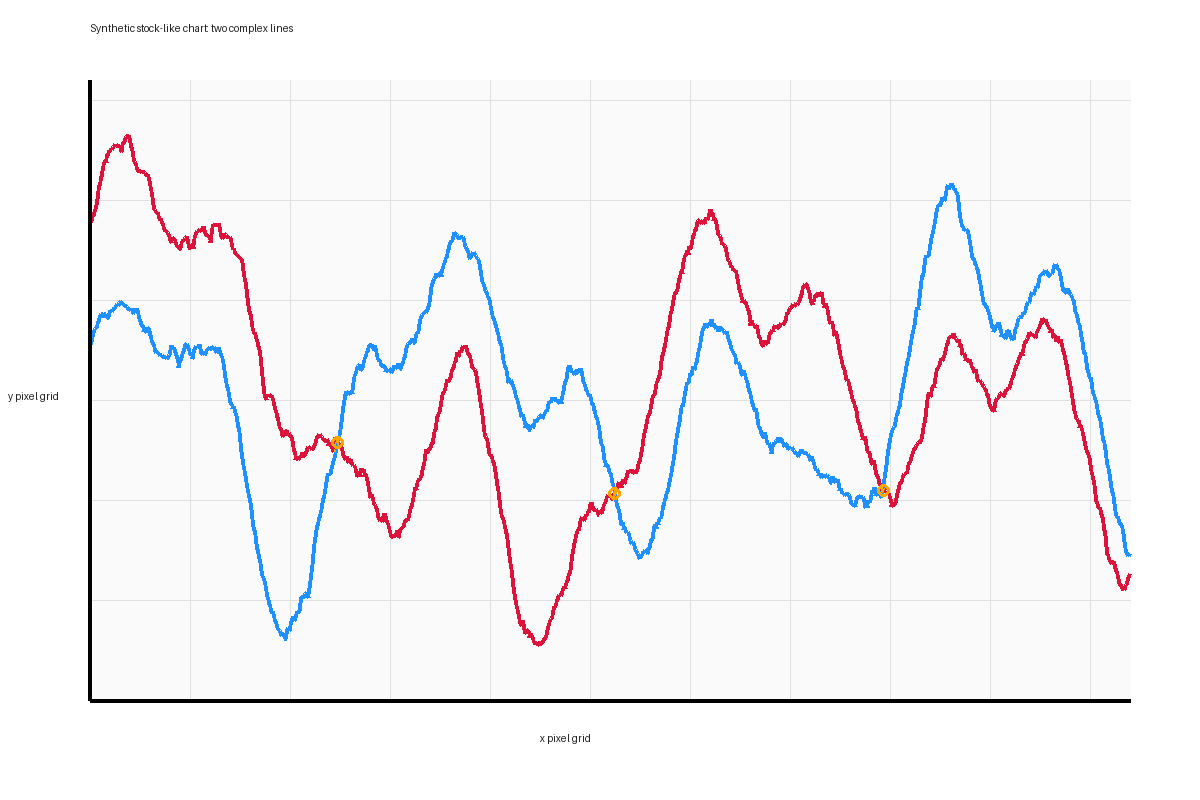

In [2]:
display(Image(filename=str(OUTPUT_DIR / "01_synthetic_stock_like_chart.png")))

## 4. Feature table

The centerline feature table contains one row per centerline pixel for each line and axis.

Important columns:

```text
x_grid, y_grid = original 2D pixel-grid coordinates
slope          = local dy/dx
curvature      = local bending
J              = y
F              = first lift
H              = final higher-dimensional lift
object_id      = source object before clustering
```

In [3]:
features = pd.read_csv(OUTPUT_DIR / "centerline_phi_feature_table.csv")
features.head()

,object_id,object_kind,x_grid,y_grid,pixel_x,pixel_y,slope,curvature,J,F,H,is_x_axis_formula,is_y_axis_formula,object_vector_cluster,H_local,sequence_lift
0,line_1,chart_line,0,477,90,223,2.0,0.000000,477.0,561.0,20561.000000,False,True,2,561.000000,20000.0
1,line_1,chart_line,1,479,91,221,2.0,0.044721,479.0,563.0,20601.013156,False,False,2,601.013156,20000.0
2,line_1,chart_line,2,481,92,219,3.0,0.007906,481.0,607.0,20613.719840,False,False,2,613.719840,20000.0
3,line_1,chart_line,3,485,93,215,2.5,0.000000,485.0,590.0,20590.000000,False,False,2,590.000000,20000.0
4,line_1,chart_line,4,486,94,214,3.0,0.015811,486.0,612.0,20625.439680,False,False,2,625.439680,20000.0


## 5. Equal-J intersections

Because `J(x,y)=y`, two chart lines intersect at the same x when their J-values are equal or nearly equal.

In [4]:
intersections = pd.read_csv(OUTPUT_DIR / "equal_J_intersections.csv")
intersections

,x_grid,J,line_1_J,line_2_J,abs_J_difference,method
0,247.454545,258.090909,258.090909,258.090909,0.0,sign_change_interpolation
1,524.000000,207.000000,207.000000,207.000000,0.0,equal_J_tolerance
2,792.571429,210.285714,210.285714,210.285714,0.0,sign_change_interpolation


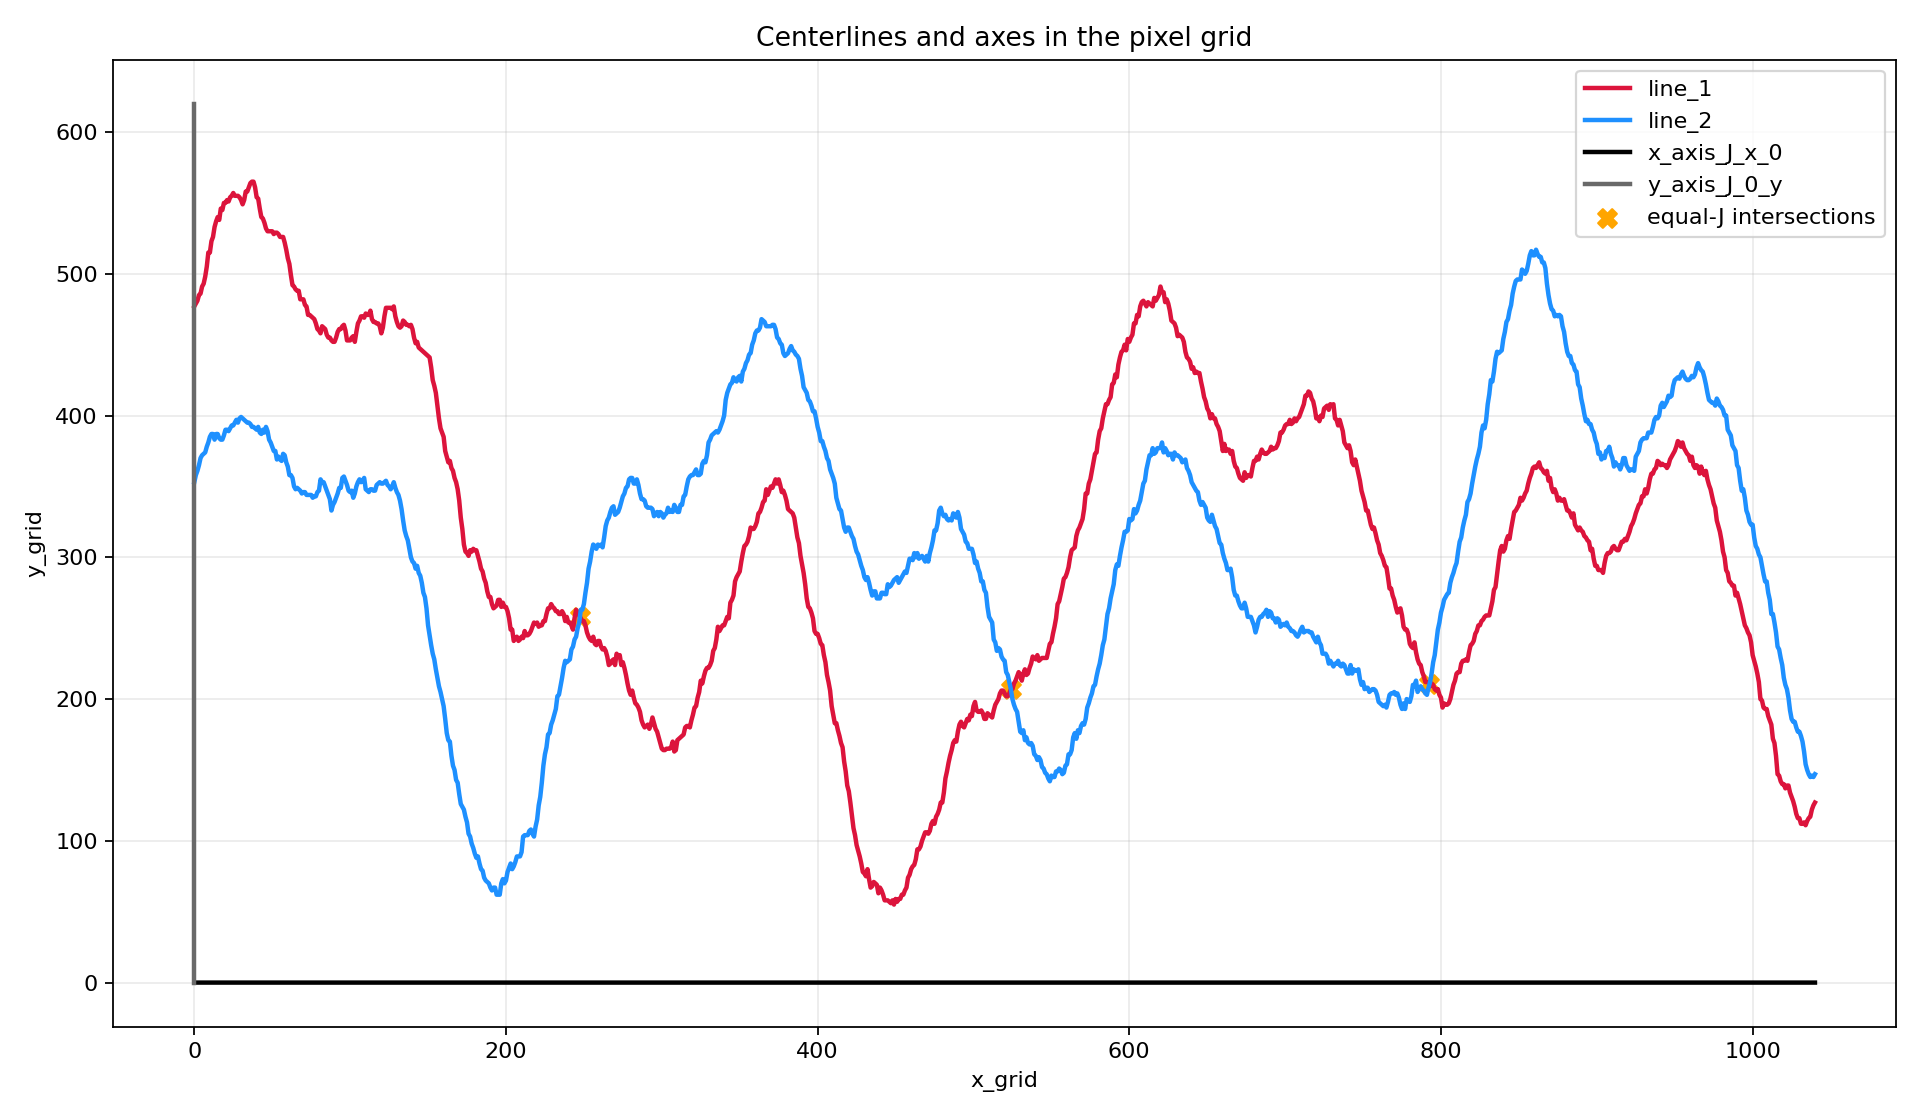

In [5]:
display(Image(filename=str(OUTPUT_DIR / "03_centerlines_axes_and_intersections_2d.png")))

## 6. Iterative dimensional lifting

The code tries progressively richer feature spaces:

```text
[x, y]
[x, y, J]
[x, y, J, slope]
[x, y, J, slope, curvature]
[x, y, slope, curvature, J, F]
[x, y, slope, curvature, J, F, H]
```

At each stage, the algorithm clusters in that feature space and then plots the cluster labels back in the original x-y chart.

In [6]:
lifting_summary = pd.read_csv(OUTPUT_DIR / "dimensional_lifting_summary.csv")
lifting_summary

,stage,features,n_features,n_clusters_found,distinctness_ratio,silhouette_score,is_distinct_enough
0,stage_01_xy,"x_grid,y_grid",2,2,1.928944,0.377326,False
1,stage_02_xy_J,"x_grid,y_grid,J",3,2,2.355634,0.440518,True
2,stage_03_xy_J_slope,"x_grid,y_grid,J,slope",4,2,1.441226,0.275361,False
3,stage_04_xy_J_slope_curvature,"x_grid,y_grid,J,slope,curvature",5,2,1.281808,0.254148,False
4,stage_05_xy_slope_curvature_J_F,"x_grid,y_grid,slope,curvature,J,F",6,2,1.621539,0.310489,False
5,stage_06_full_Phi,"x_grid,y_grid,slope,curvature,J,F,H",7,2,7.404469,0.814501,True


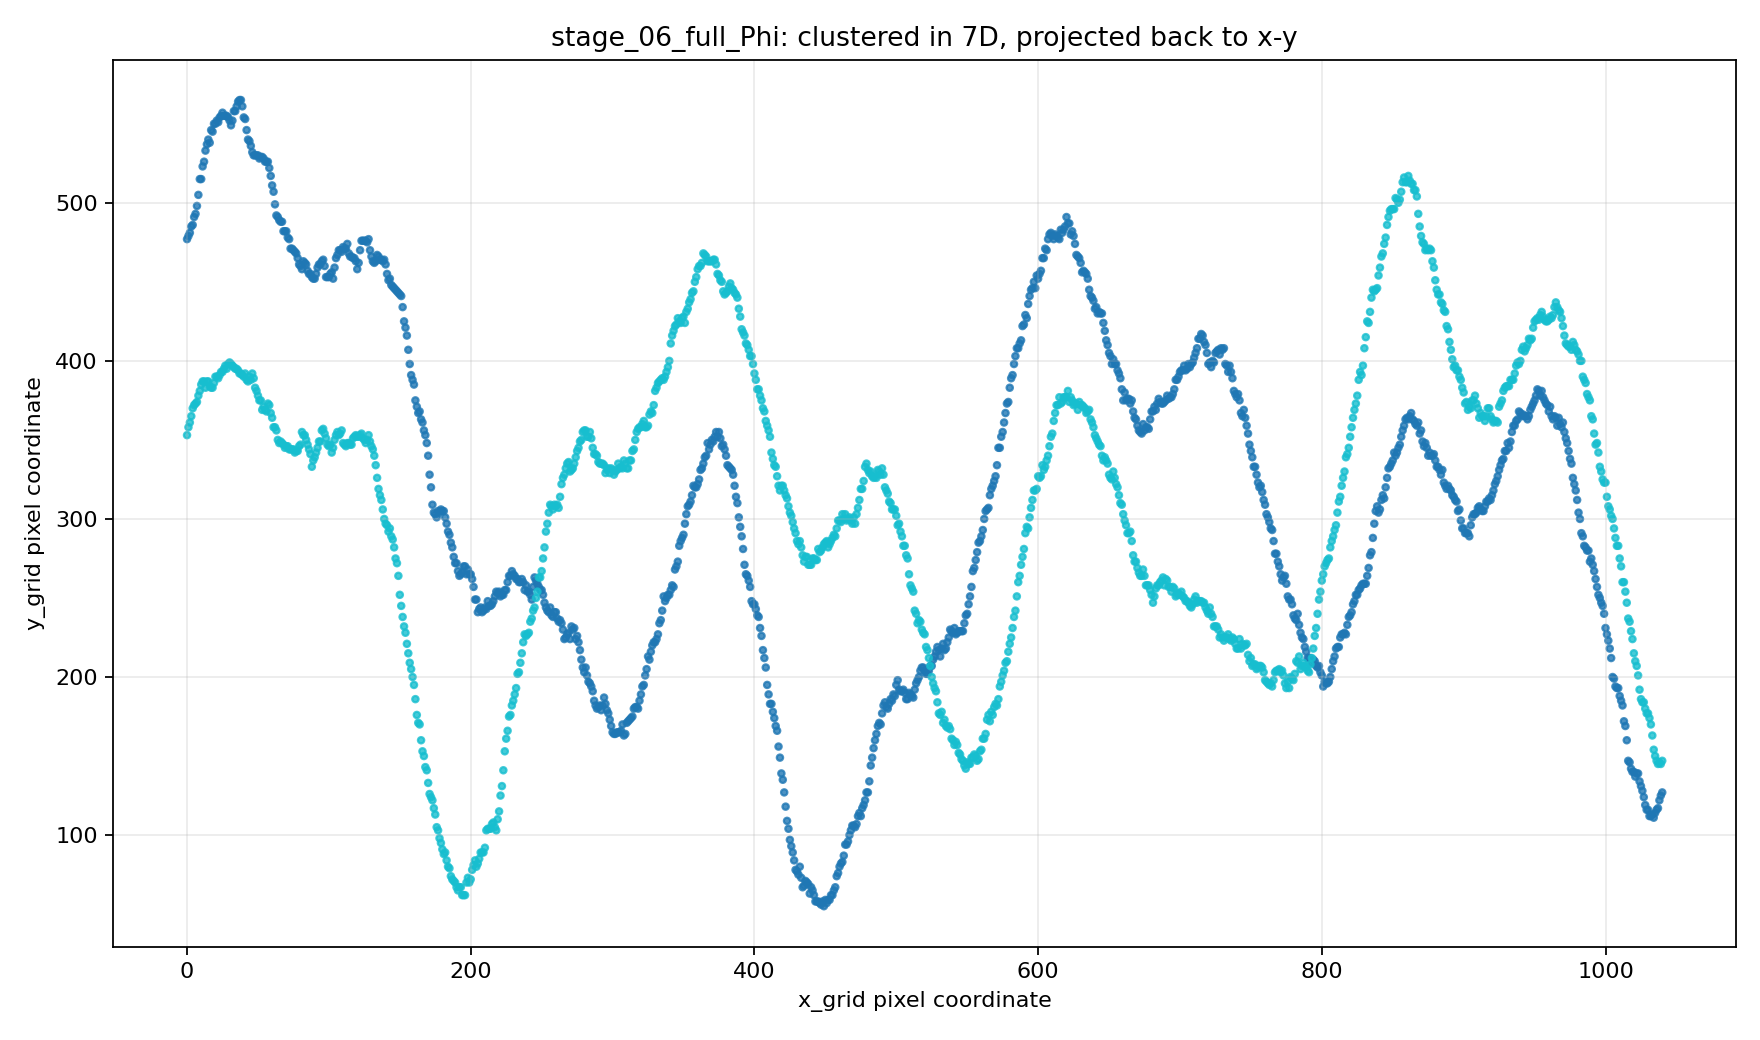

In [7]:
# Display the final full-Phi lifting-stage projection.
display(Image(filename=str(OUTPUT_DIR / "dimensional_lifting_stages" / "stage_06_full_Phi_projected_to_xy.png")))

## 7. Full Phi-space clustering projected back to 2D

The clustering is performed using:

```text
Phi(x,y) = [x, y, slope, curvature, J, F, H]
```

The output below shows the resulting line clusters in the original pixel grid.

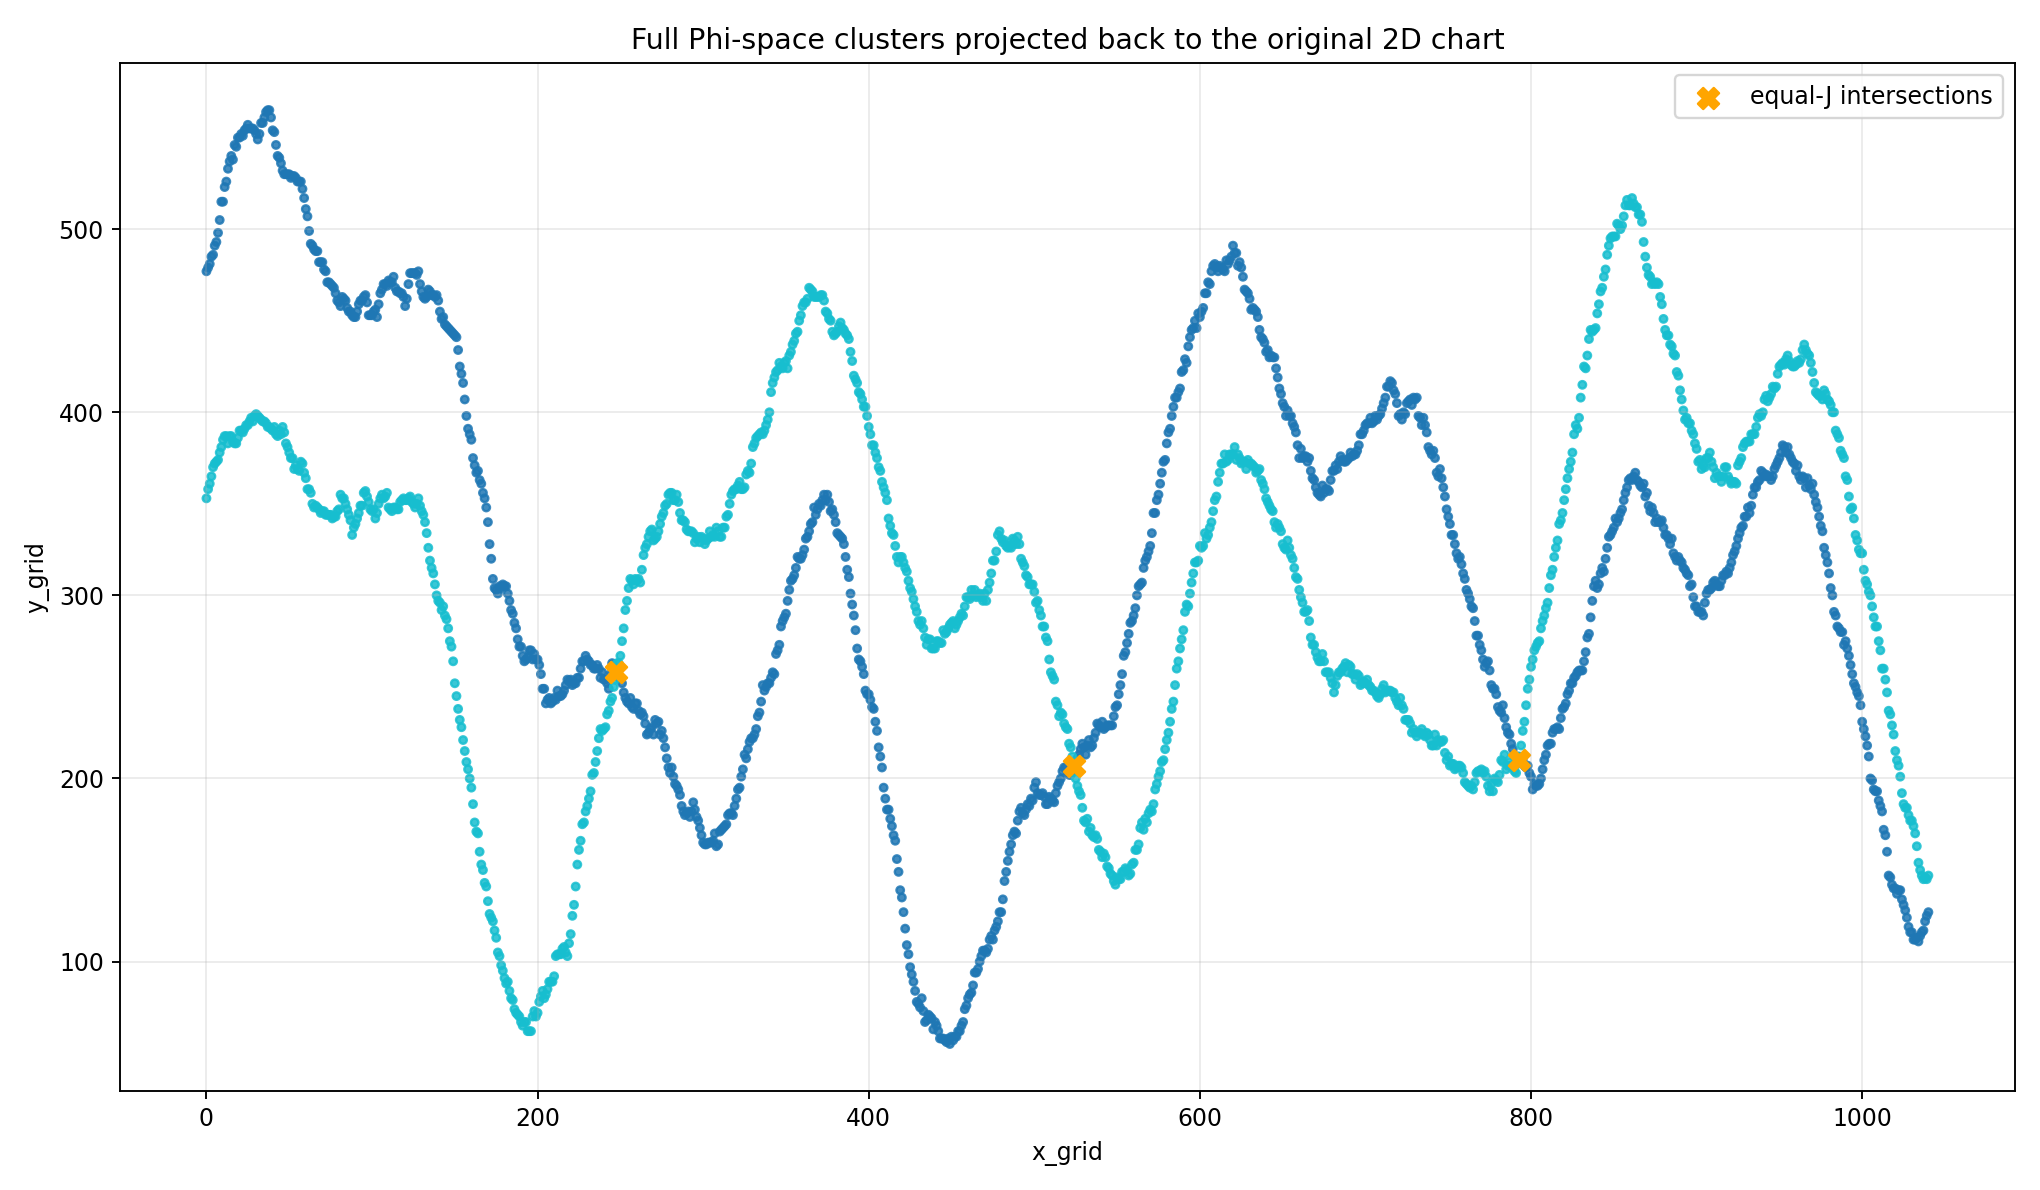

In [8]:
display(Image(filename=str(OUTPUT_DIR / "04_full_phi_clusters_projected_to_2d.png")))

## 8. Axes plus line clusters

Axes are included as clusterable objects:

```text
x-axis = J(x,0)
y-axis = J(0,y)
```

The plot below shows the axes and the Phi-space line clusters together.

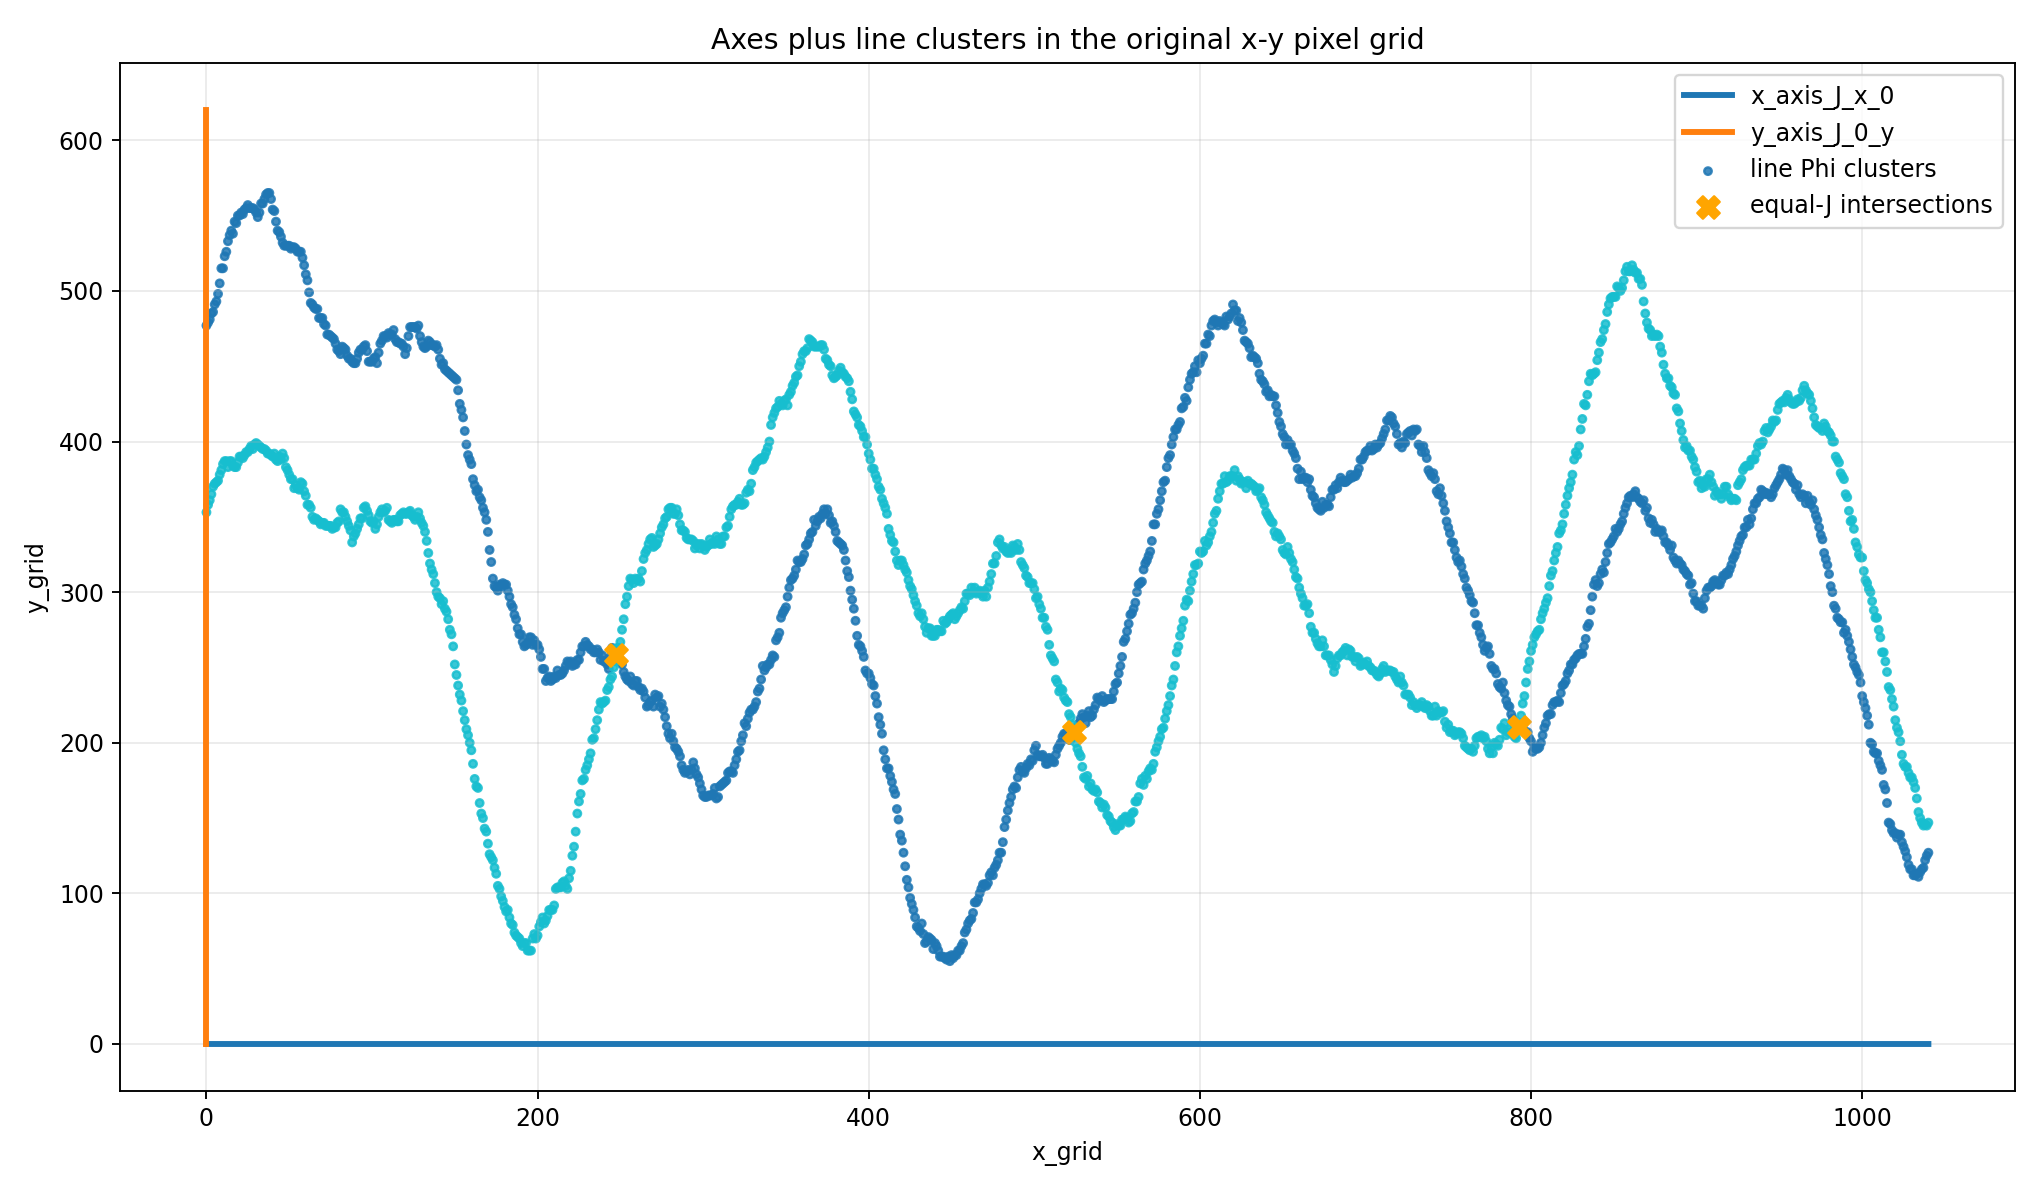

In [9]:
display(Image(filename=str(OUTPUT_DIR / "05_axes_and_phi_line_clusters_2d.png")))

## 9. 3D visualization with J

This view shows `(x, y, J)` with cluster colors determined by the higher-dimensional Phi clustering.

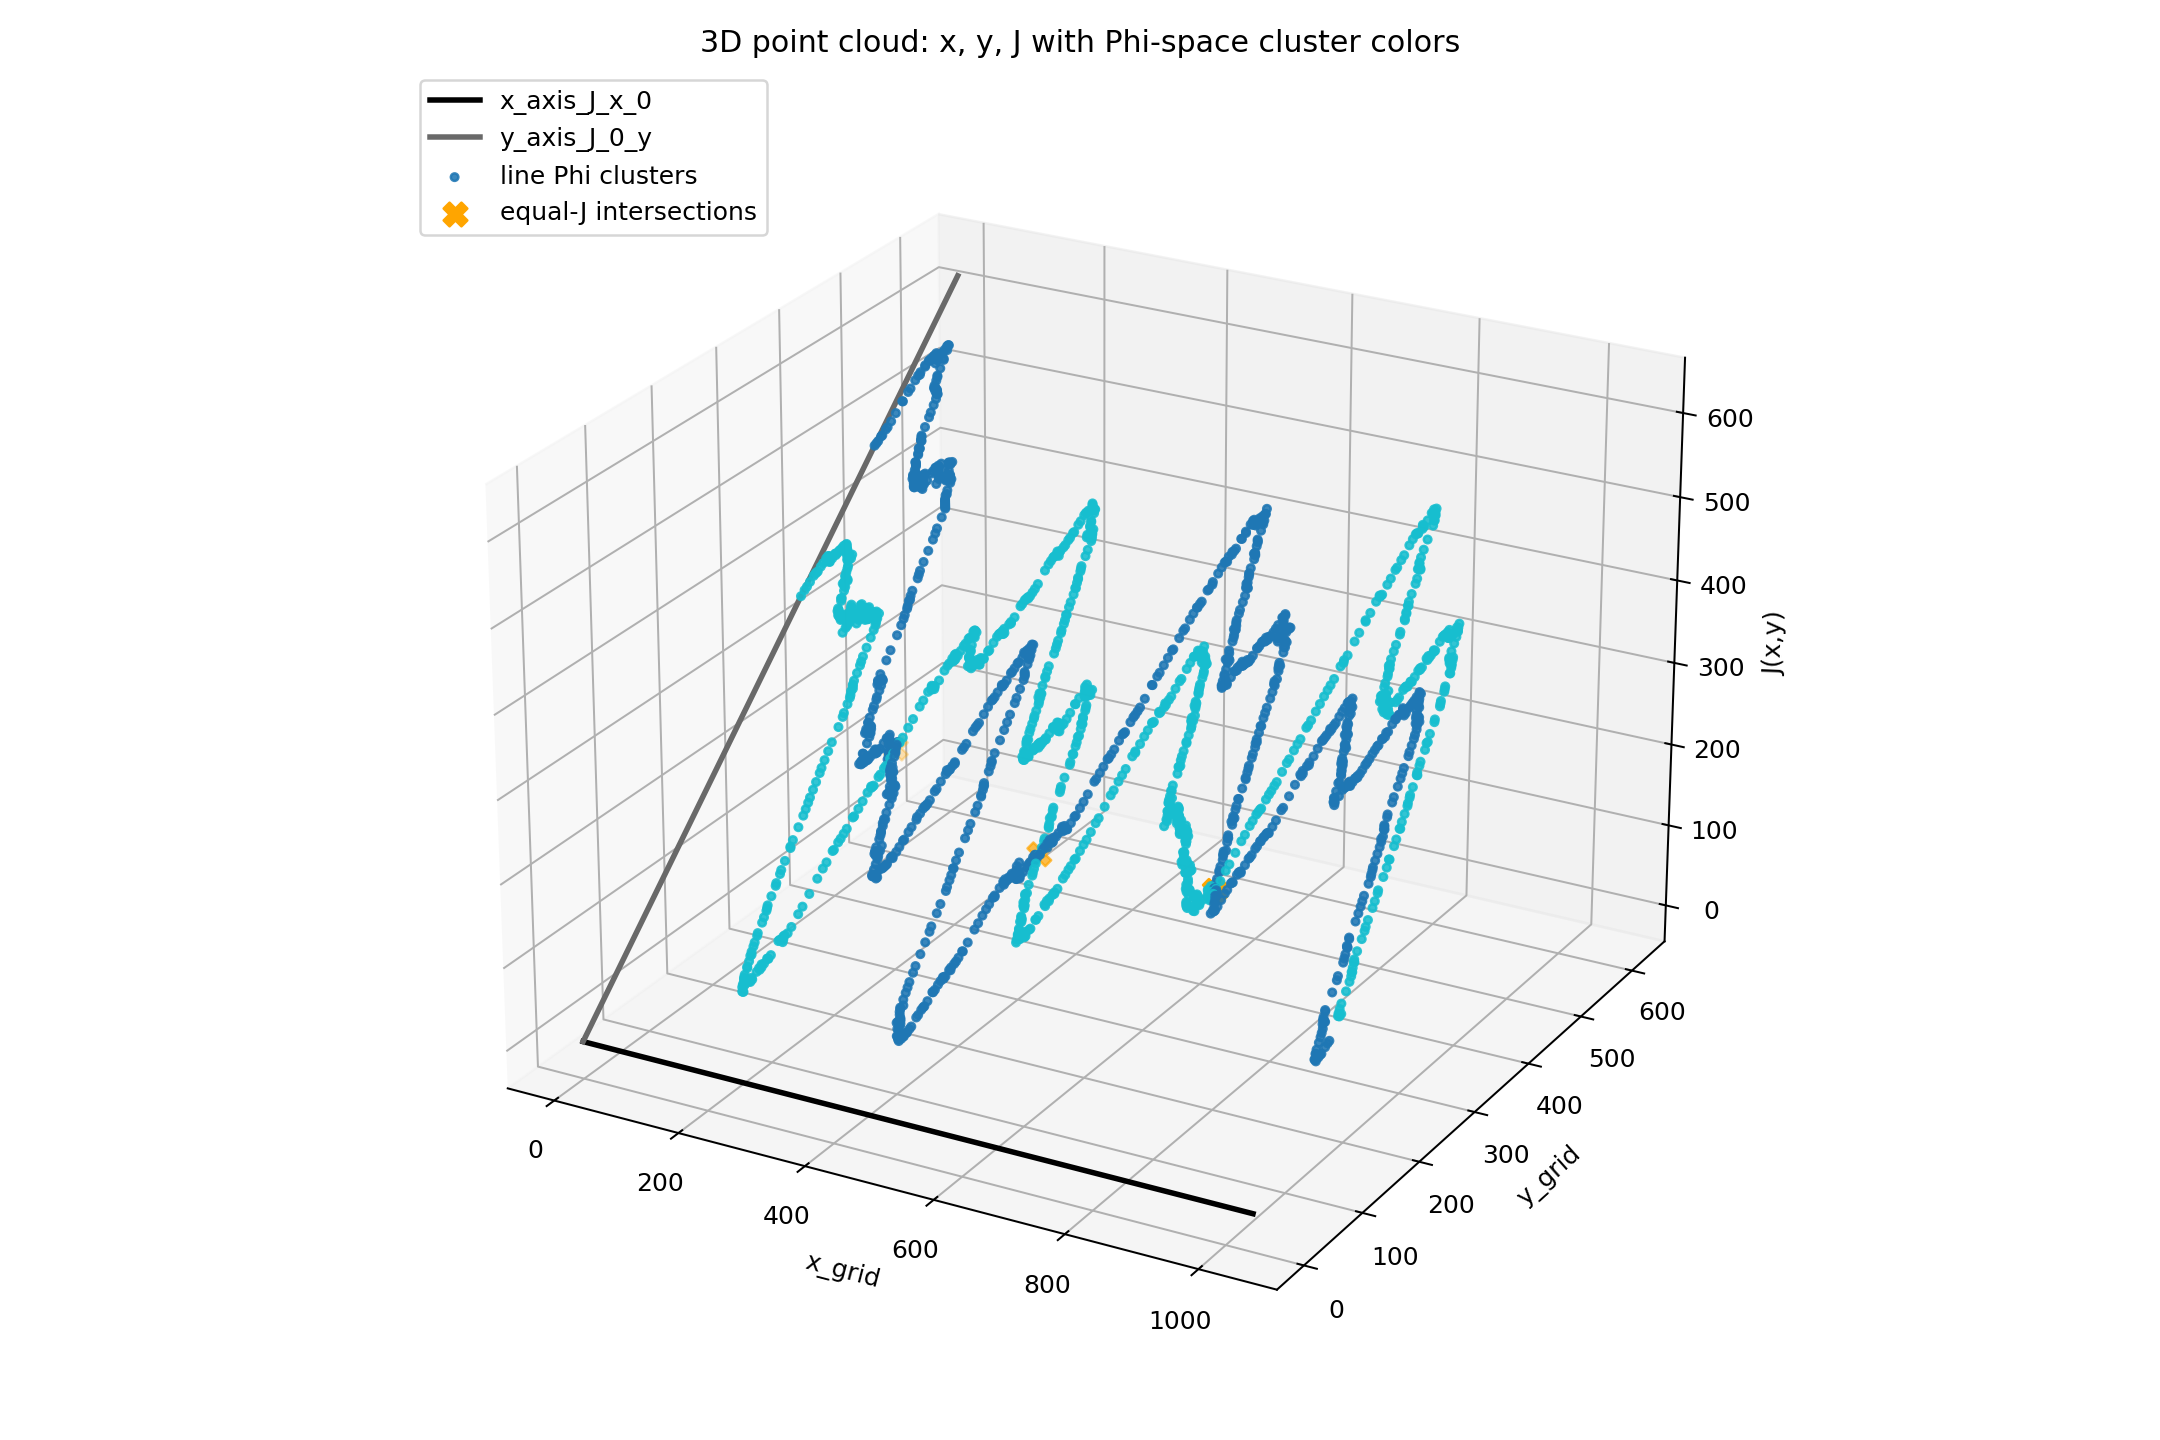

In [10]:
display(Image(filename=str(OUTPUT_DIR / "06_3d_x_y_J_phi_clusters.png")))

## 10. Whole-line J-vector clustering

Each full object is represented as a fixed-length sequence of J-values.

```text
line_1_vector = [J_1(x_0), J_1(x_1), ..., J_1(x_n)]
line_2_vector = [J_2(x_0), J_2(x_1), ..., J_2(x_n)]
x_axis_vector = [0, 0, ..., 0]
y_axis_vector = [J(0,y_0), J(0,y_1), ..., J(0,y_n)]
```

The code clusters those whole-object vectors and uses that cluster as the final lift inside `H`.

In [11]:
object_clusters = pd.read_csv(OUTPUT_DIR / "whole_object_vector_clusters.csv")
object_clusters

,object_id,object_vector_cluster
0,line_1,2
1,line_2,0
2,x_axis_J_x_0,3
3,y_axis_J_0_y,1


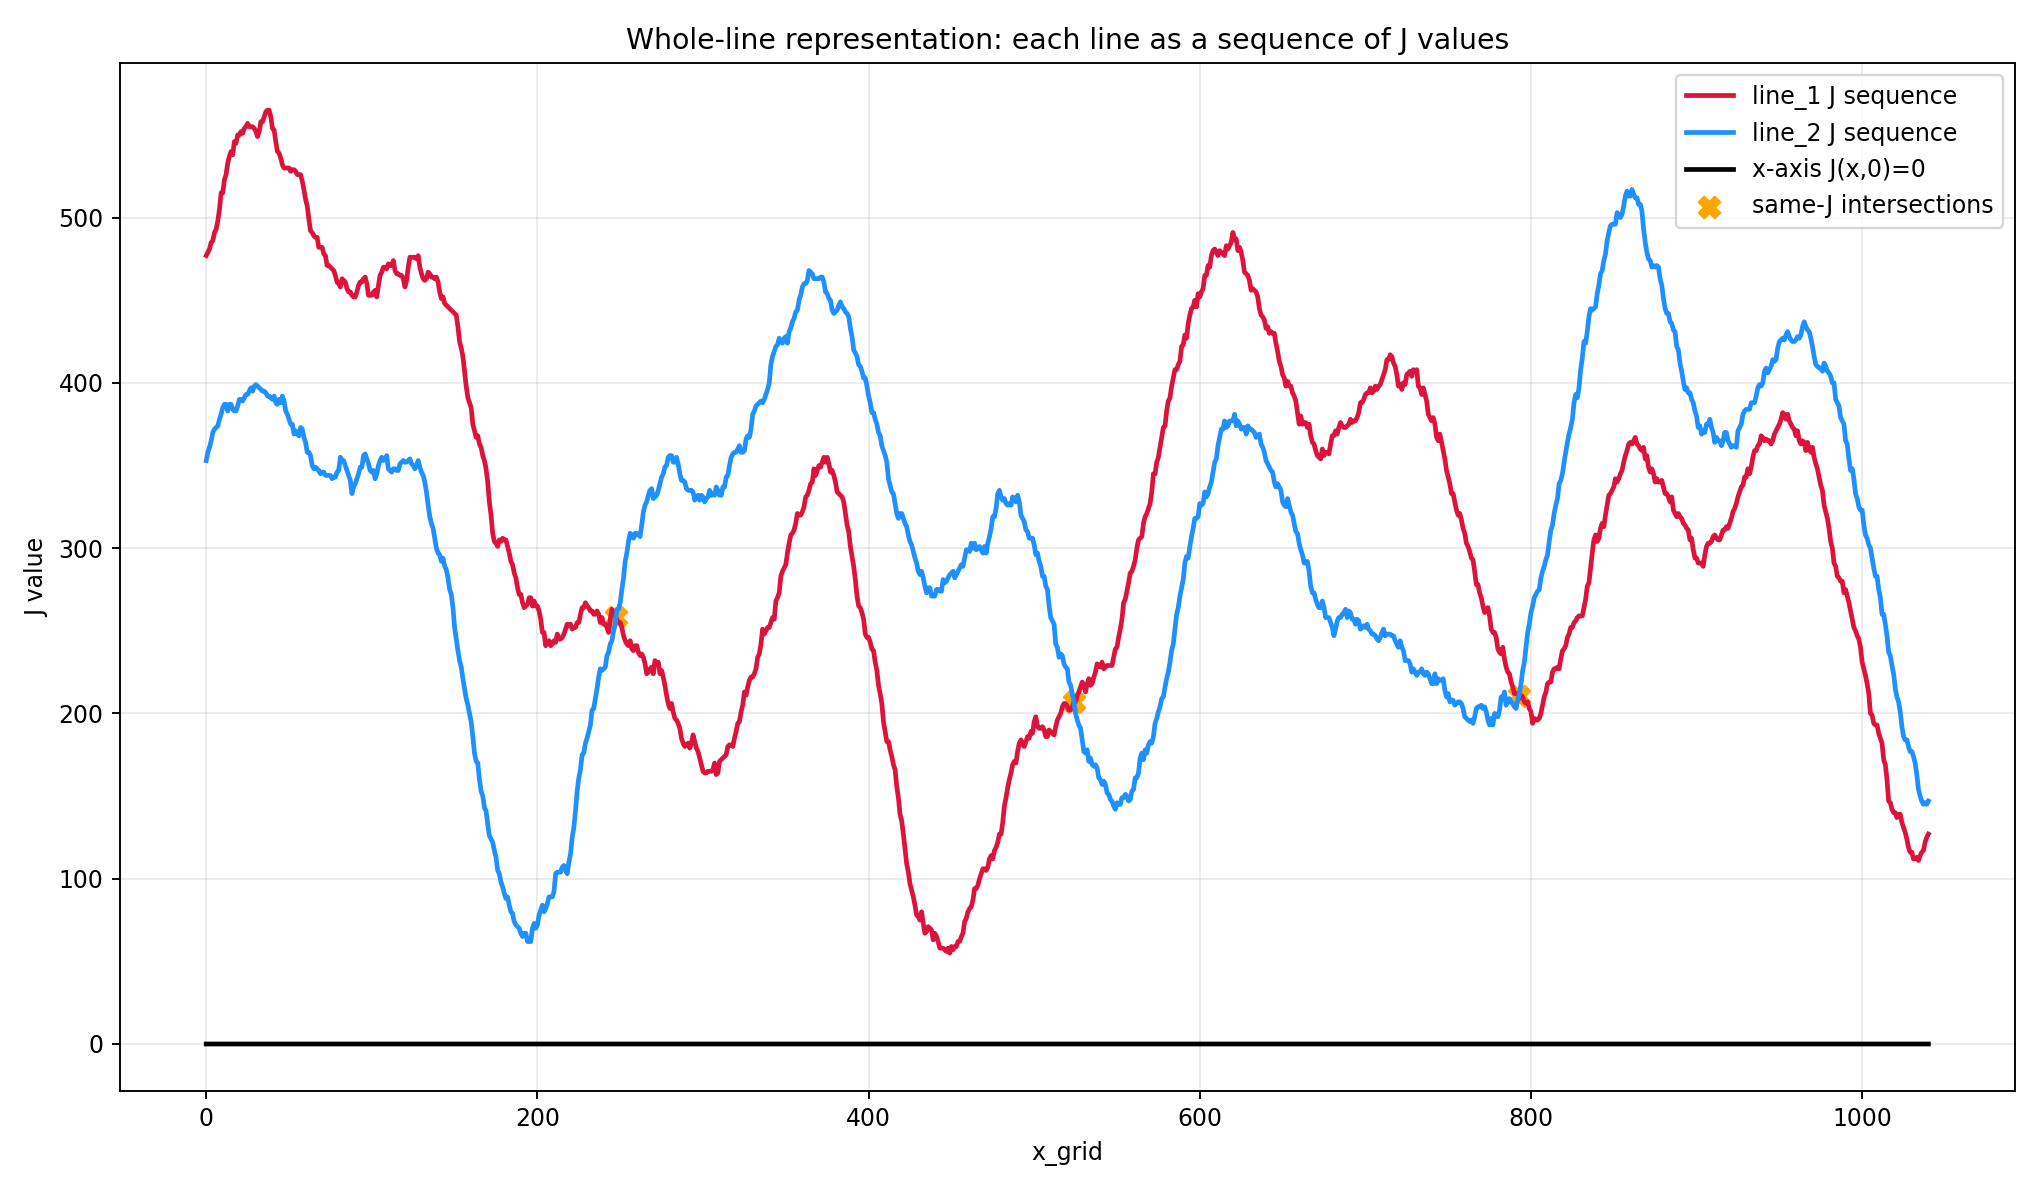

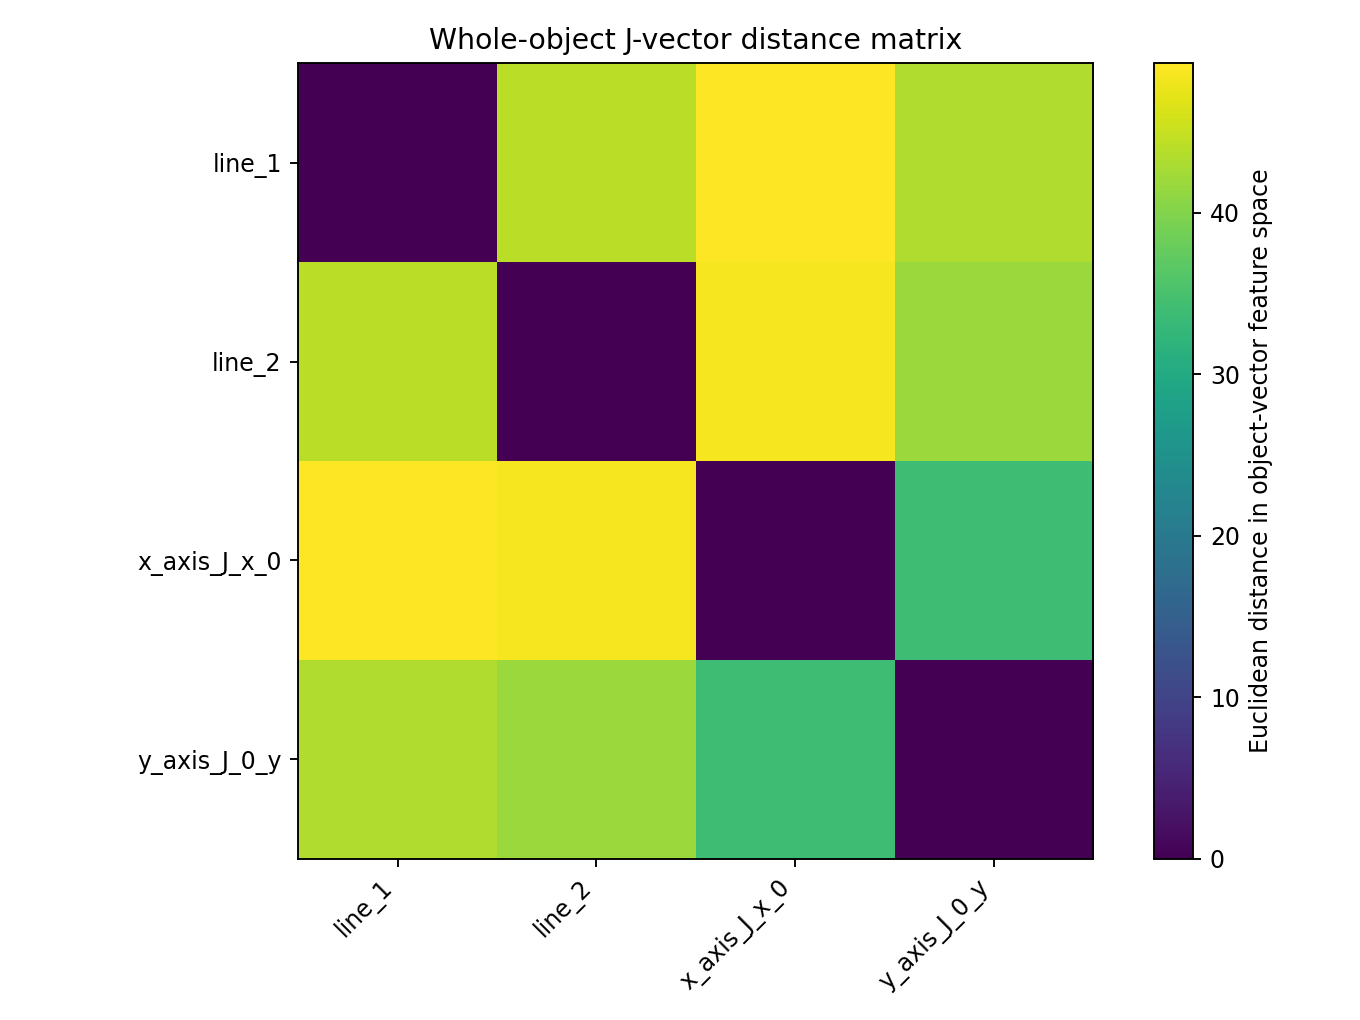

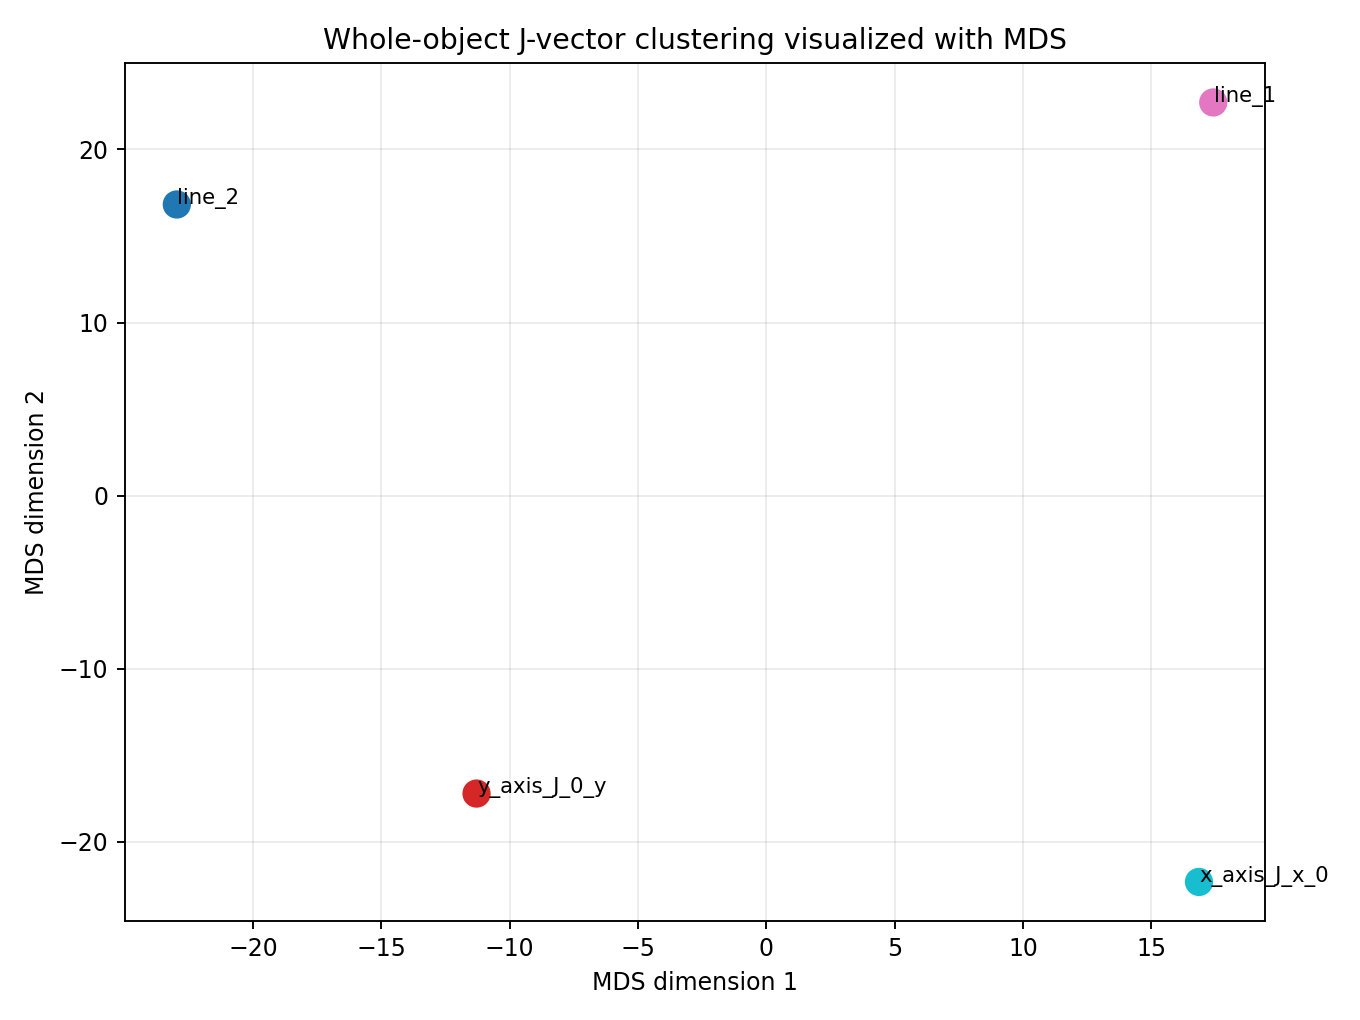

In [12]:
display(Image(filename=str(OUTPUT_DIR / "07_whole_line_J_sequences.png")))
display(Image(filename=str(OUTPUT_DIR / "08_whole_object_vector_distance_heatmap.png")))
display(Image(filename=str(OUTPUT_DIR / "09_whole_object_vector_mds_clusters.png")))

## 11. Interactive 3D plot

Open the generated HTML file in a browser to rotate and zoom the `(x, y, J)` point cloud.

In [ ]:
interactive_path = OUTPUT_DIR / "10_interactive_3d_x_y_J_phi_clusters.html"
print(interactive_path)
# In Jupyter, uncomment the next line to embed the interactive plot.
# display(HTML(interactive_path.read_text()))